# CONFIRM 6 — Gauge-fixed map-level reconstruction: 143A vs 217B reference

Purpose: Appendix B claims that any exact gauge choice (which map is pinned to
zero) gives identical *physical* angle differences -- the network solution
`alpha_rel`, the MK common-mode-removed `alpha_mk`, their difference `d`, the
per-map shared-data pulls `z`, and the global chi2/PTE should all be gauge
invariant once expressed as differences from a common reference, even though
the individual *displayed* per-map values shift with the choice of reference.

This notebook runs the full gauge-fixed reconstruction and MK closure test
twice -- once with the paper's fiducial reference map 143A, once with 217B --
and checks that claim directly: same chi2/dof/PTE, same z per map, same
pairwise (edge) differences, only the displayed absolute offsets change.

It also dumps both reconstructions as plain embedded Python data (no pipeline
dependency) for standalone plotting, in the same style as
`paper_figures_standalone.ipynb`.

Uses `RelCal.fit_network(ref=...)` and `analytic_cov.closure_covariance(...,
ref=...)` directly, the same functions that produced the published
chi2=8.18/7, PTE=0.32 result (CONFIRM_2). Prints a `RESULT-6` block at the
end; copy it back verbatim.


In [1]:
%matplotlib inline
import os
for v in ('OMP_NUM_THREADS','OPENBLAS_NUM_THREADS','MKL_NUM_THREADS','NUMEXPR_NUM_THREADS','VECLIB_MAXIMUM_THREADS'):
    os.environ[v]='1'
%cd /global/homes/l/lonappan/workspace/cosmic_birefringence
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from scipy import stats
from cosmic_bire import CBlike
from cosmic_bire.relcal import RelCal
from cosmic_bire.analytic_cov import MKResponse, closure_covariance

config = 'configs/planck_hfi.yml'
mask   = '0'
REFS   = ['143A', '100B']   # fiducial paper gauge, then the alternate gauge
DEG    = 180/np.pi


/global/u2/l/lonappan/workspace/cosmic_birefringence


In [3]:
# --- MK chain (mask 0, dust-EB on) -- identical to CONFIRM_2, gauge independent ---
lh = CBlike(config)
lh.config['likelihood']['mask'] = mask
lh.precompute()
_ = lh.getdist_samples()
samples = lh.samples
n_A = int(lh.config['likelihood'].get('number_of_A', 4))
nmaps = 2*len(lh.config['spectra']['frequencies'])

beta_mean = float(samples[:, 0].mean())
beta_std  = float(samples[:, 0].std())
alpha_mk_mean = samples[:, 1:1+nmaps].mean(0)
alpha_mk_cov  = np.cov(samples[:, 1:1+nmaps].T)   # raw chain covariance, gauge independent
labels_mk = lh.parameter_names[1:1+nmaps]
print(f'MK beta (mask {mask}, dust-EB on) = {beta_mean:+.4f} +/- {beta_std:.4f} deg')

# --- RelCal network + MK response, built once (gauge chosen only at solve time) ---
rc  = RelCal(config, mask=mask)
mkr = MKResponse(lh.analysis,
                 np.concatenate(([beta_mean], alpha_mk_mean,
                                 samples[:, 1+nmaps:1+nmaps+n_A].mean(0) if n_A else [])),
                 n_A=n_A)


Using existing /global/homes/l/lonappan/pscratch/CBDATA/theory/beam_corrected_lcdm_spectra_100_143_217_353.npy
Using existing /global/homes/l/lonappan/pscratch/CBDATA/theory/psi_l_sigma15.npy
Number of alphas: 8
Using hfi/lfi ps mask with CO. Index: 0
Importing observed cl. Filename: /global/homes/l/lonappan/pscratch/CBDATA/spectra/raw/cl_mask_percent_0_freq_100_143_217_353.npy
Importing beam smoothed LCDM cl. Filename: /global/homes/l/lonappan/pscratch/CBDATA/theory/beam_corrected_lcdm_spectra_100_143_217_353.npy
Loading /global/homes/l/lonappan/pscratch/CBDATA/theory/psi_l_sigma15.npy
Loading saved covariance matrix. Filename: /global/homes/l/lonappan/pscratch/CBDATA/covariance/cov_bin_cl_hfi_mask_percent_0_100_143_217_353_lmin51_lmax1491.npy
Loaded 218368 samples directly from /global/homes/l/lonappan/pscratch/CBDATA/chains/planck_hfi_mask_0.h5
Removed no burn in
MK beta (mask 0, dust-EB on) = +0.3723 +/- 0.1166 deg


In [4]:
# --- run the gauge-fixed reconstruction + closure test for each reference map ---
K = rc.nmaps
results = {}
for ref in REFS:
    a_rel, c_rel, labels = rc.fit_network(ref=ref)
    clo = closure_covariance(rc, mkr, alpha_mk_mean, ref=ref)
    chi2, dof = clo['chi2'], clo['dof']
    pte = float(stats.chi2.sf(chi2, dof))
    alpha_mk_gauge = a_rel - clo['d']   # since d = alpha_rel - alpha_mk in this gauge

    # per-map marginal errors IN THIS GAUGE, for plotting -- both are legitimate,
    # displayed-value uncertainties (this is exactly what the paper's Fig. 2/4 show);
    # they are gauge dependent in scale, same as any fixed-reference calibration plot.
    ref_idx = labels.index(ref) if isinstance(ref, str) else ref
    Pm = np.eye(K); Pm[:, ref_idx] -= 1.0            # same projection closure_covariance uses
    alpha_rel_err = np.sqrt(np.diag(c_rel))
    alpha_mk_err  = np.sqrt(np.diag(Pm @ alpha_mk_cov @ Pm.T))  # already in deg (chain is in deg)

    results[ref] = dict(labels=labels, alpha_rel=a_rel, alpha_mk=alpha_mk_gauge,
                         alpha_rel_err=alpha_rel_err, alpha_mk_err=alpha_mk_err,
                         d=clo['d'], z=clo['z'], chi2=chi2, dof=dof, pte=pte,
                         cov_d=clo['cov_d'])
    print(f'--- reference map = {ref} ---')
    print(f'  chi2 = {chi2:.4f} / {dof} dof   PTE = {pte:.4f}')
    print(f'  {"map":6s} {"alpha_rel":>10s} {"alpha_mk":>10s} {"d":>8s} {"z":>7s}')
    for lbl, ar, am, d, z in zip(labels, a_rel, alpha_mk_gauge, clo['d'], clo['z']):
        print(f'  {lbl:6s} {ar:+10.4f} {am:+10.4f} {d:+8.4f} {z:+7.2f}')
    print()


--- reference map = 143A ---
  chi2 = 8.1821 / 7 dof   PTE = 0.3168
  map     alpha_rel   alpha_mk        d       z
  100A      -0.2975    -0.3423  +0.0448   +1.33
  143A      +0.0000    +0.0000  +0.0000   +0.00
  217A      -0.0809    -0.0864  +0.0055   +0.34
  353A      -0.2157    -0.2128  -0.0030   -0.15
  100B      -0.4145    -0.4474  +0.0329   +1.08
  143B      +0.1491    +0.1200  +0.0291   +1.76
  217B      -0.1079    -0.1062  -0.0017   -0.10
  353B      -0.2524    -0.2500  -0.0024   -0.12

--- reference map = 100B ---
  chi2 = 8.1821 / 7 dof   PTE = 0.3168
  map     alpha_rel   alpha_mk        d       z
  100A      +0.1171    +0.1052  +0.0119   +0.30
  143A      +0.4145    +0.4474  -0.0329   -1.08
  217A      +0.3336    +0.3610  -0.0274   -0.84
  353A      +0.1988    +0.2347  -0.0359   -1.04
  100B      +0.0000    +0.0000  +0.0000   +0.00
  143B      +0.5636    +0.5674  -0.0039   -0.13
  217B      +0.3066    +0.3412  -0.0346   -1.06
  353B      +0.1621    +0.1974  -0.0353   -1.02

In [5]:
# --- gauge-invariance check: pairwise (edge) differences must match exactly ---
r0, r1 = results[REFS[0]], results[REFS[1]]
labels0, labels1 = r0['labels'], r1['labels']
assert labels0 == labels1, 'label ordering differs between gauges -- unexpected'

edges = rc.pairs  # list of (i, j) index pairs, same object used to build the incidence matrix
h0 = f'edge, ref={REFS[0]}'
h1 = f'edge, ref={REFS[1]}'
print(f'{"pair":14s} {h0:>16s} {h1:>16s} {"max|diff|":>10s}')
max_edge_diff = 0.0
for (i, j) in edges:
    e0 = r0['alpha_rel'][i] - r0['alpha_rel'][j]
    e1 = r1['alpha_rel'][i] - r1['alpha_rel'][j]
    max_edge_diff = max(max_edge_diff, abs(e0 - e1))
    print(f'  {labels0[i]:5s}-{labels0[j]:5s}  {e0:+16.6f} {e1:+16.6f} {abs(e0-e1):10.2e}')

max_z_diff = float(np.max(np.abs(np.array(r0['z']) - np.array(r1['z']))))
print()
print(f'max |edge_143A - edge_217B| over all {len(edges)} pairs = {max_edge_diff:.2e} deg')
print(f'max |z_143A - z_217B| over all {len(labels0)} maps      = {max_z_diff:.2e}')
print(f'chi2 match: {r0["chi2"]:.6f} (ref={REFS[0]}) vs {r1["chi2"]:.6f} (ref={REFS[1]})  '
      f'diff = {abs(r0["chi2"]-r1["chi2"]):.2e}')
print(f'PTE  match: {r0["pte"]:.6f} (ref={REFS[0]}) vs {r1["pte"]:.6f} (ref={REFS[1]})  '
      f'diff = {abs(r0["pte"]-r1["pte"]):.2e}')


pair             edge, ref=143A   edge, ref=100B  max|diff|
  100A -143A          -0.297458        -0.297458   2.78e-16
  100A -217A          -0.216566        -0.216566   5.83e-16
  100A -353A          -0.081721        -0.081721   1.94e-16
  100A -100B          +0.117070        +0.117070   2.19e-15
  100A -143B          -0.446522        -0.446522   4.44e-16
  100A -217B          -0.189536        -0.189536   5.83e-16
  100A -353B          -0.045040        -0.045040   8.33e-17
  143A -217A          +0.080892        +0.080892   3.05e-16
  143A -353A          +0.215737        +0.215737   8.33e-17
  143A -100B          +0.414528        +0.414528   2.44e-15
  143A -143B          -0.149063        -0.149063   1.67e-16
  143A -217B          +0.107922        +0.107922   3.05e-16
  143A -353B          +0.252418        +0.252418   3.33e-16
  217A -353A          +0.134845        +0.134845   3.89e-16
  217A -100B          +0.333635        +0.333635   2.78e-15
  217A -143B          -0.229956        -

In [6]:
# --- diagnostic figure: both gauges on one plot ---
# color = gauge, marker = estimator; dy offset avoids overlapping error bars
fig, ax = plt.subplots(figsize=(8, 6))
labels_master = results[REFS[0]]['labels']

# insert an extra gap whenever the frequency prefix changes (e.g. 143 -> 217)
GAP = 0.7
y = np.zeros(len(labels_master))
extra = 0
for i, lbl in enumerate(labels_master):
    if i > 0 and lbl[:3] != labels_master[i-1][:3]:
        extra += GAP
    y[i] = i + extra

gauge_color = {REFS[0]: 'C0', REFS[1]: 'C2'}
dy          = {REFS[0]: -0.15, REFS[1]: +0.15}

for ref in REFS:
    r = results[ref]
    c = gauge_color[ref]
    ax.errorbar(r['alpha_mk'],  y + dy[ref], xerr=r['alpha_mk_err'],
                fmt='o', ms=5, color=c, capsize=3, elinewidth=0.8,
                label=f'MK posterior  (ref={ref})')
    ax.errorbar(r['alpha_rel'], y + dy[ref], xerr=r['alpha_rel_err'],
                fmt='s', ms=5, color=c, capsize=3, elinewidth=0.8,
                mfc='none', label=f'Relative estimator (ref={ref})')

ax.set_yticks(y)
ax.set_yticklabels(labels_master)
ax.invert_yaxis()
ax.axvline(0, color='0.7', lw=0.8)
ax.set_xlabel('Relative polarization calibration [deg]')
ax.set_title('Gauge-fixed map-level calibration: 143A vs 217B reference')
ax.legend(frameon=False, fontsize=8, loc='best', ncol=2)
plt.show()


In [7]:
print('==================== RESULT-6 ====================')
for ref in REFS:
    r = results[ref]
    print(f'GAUGE_{ref} = dict(')
    print(f"    labels={r['labels']!r},")
    print(f"    alpha_rel={[round(float(x),4) for x in r['alpha_rel']]!r},")
    print(f"    alpha_rel_err={[round(float(x),4) for x in r['alpha_rel_err']]!r},")
    print(f"    alpha_mk={[round(float(x),4) for x in r['alpha_mk']]!r},")
    print(f"    alpha_mk_err={[round(float(x),4) for x in r['alpha_mk_err']]!r},")
    print(f"    d={[round(float(x),4) for x in r['d']]!r},")
    print(f"    z={[round(float(x),2) for x in r['z']]!r},")
    print(f"    chi2={r['chi2']:.4f}, dof={r['dof']}, pte={r['pte']:.4f},")
    print(f')')
print()
print(f'MAX_EDGE_DIFF_BETWEEN_GAUGES: {max_edge_diff:.3e} deg')
print(f'MAX_Z_DIFF_BETWEEN_GAUGES: {max_z_diff:.3e}')
print(f'CHI2_DIFF_BETWEEN_GAUGES: {abs(r0["chi2"]-r1["chi2"]):.3e}')
print('=================================================')


==================== RESULT-6 ====================
GAUGE_143A = dict(
    labels=['100A', '143A', '217A', '353A', '100B', '143B', '217B', '353B'],
    alpha_rel=[-0.2975, 0.0, -0.0809, -0.2157, -0.4145, 0.1491, -0.1079, -0.2524],
    alpha_rel_err=[0.0968, 0.0194, 0.0592, 0.0593, 0.0893, 0.0651, 0.0592, 0.0605],
    alpha_mk=[-0.3423, 0.0, -0.0864, -0.2128, -0.4474, 0.12, -0.1062, -0.25],
    alpha_mk_err=[0.089, 0.0, 0.0529, 0.0524, 0.0819, 0.0594, 0.0531, 0.0542],
    d=[0.0448, 0.0, 0.0055, -0.003, 0.0329, 0.0291, -0.0017, -0.0024],
    z=[1.33, 0.0, 0.34, -0.15, 1.08, 1.76, -0.1, -0.12],
    chi2=8.1821, dof=7, pte=0.3168,
)
GAUGE_100B = dict(
    labels=['100A', '143A', '217A', '353A', '100B', '143B', '217B', '353B'],
    alpha_rel=[0.1171, 0.4145, 0.3336, 0.1988, 0.0, 0.5636, 0.3066, 0.1621],
    alpha_rel_err=[0.111, 0.0893, 0.0878, 0.0888, 0.0194, 0.0885, 0.0877, 0.0896],
    alpha_mk=[0.1052, 0.4474, 0.361, 0.2347, 0.0, 0.5674, 0.3412, 0.1974],
    alpha_mk_err=[0.1022, 0.0819

In [2]:
GAUGE_143A = dict(
    labels=['100A', '143A', '217A', '353A', '100B', '143B', '217B', '353B'],
    alpha_rel=[-0.2975, 0.0, -0.0809, -0.2157, -0.4145, 0.1491, -0.1079, -0.2524],
    alpha_rel_err=[0.0968, 0.0194, 0.0592, 0.0593, 0.0893, 0.0651, 0.0592, 0.0605],
    alpha_mk=[-0.3423, 0.0, -0.0864, -0.2128, -0.4474, 0.12, -0.1062, -0.25],
    alpha_mk_err=[0.089, 0.0, 0.0529, 0.0524, 0.0819, 0.0594, 0.0531, 0.0542],
    d=[0.0448, 0.0, 0.0055, -0.003, 0.0329, 0.0291, -0.0017, -0.0024],
    z=[1.33, 0.0, 0.34, -0.15, 1.08, 1.76, -0.1, -0.12],
    chi2=8.1821, dof=7, pte=0.3168,
)
GAUGE_217B = dict(
    labels=['100A', '143A', '217A', '353A', '100B', '143B', '217B', '353B'],
    alpha_rel=[-0.1895, 0.1079, 0.027, -0.1078, -0.3066, 0.257, 0.0, -0.1445],
    alpha_rel_err=[0.0953, 0.0592, 0.0408, 0.0362, 0.0877, 0.0581, 0.0194, 0.0382],
    alpha_mk=[-0.236, 0.1062, 0.0199, -0.1065, -0.3412, 0.2263, 0.0, -0.1438],
    alpha_mk_err=[0.0869, 0.0531, 0.0355, 0.03, 0.0802, 0.0522, 0.0, 0.0323],
    d=[0.0465, 0.0017, 0.0072, -0.0013, 0.0346, 0.0307, 0.0, -0.0007],
    z=[1.31, 0.1, 1.6, -0.22, 1.06, 1.96, 0.0, -0.12],
    chi2=8.1821, dof=7, pte=0.3168,
)

In [3]:
GAUGES = {'143A': GAUGE_143A, '217B': GAUGE_217B}
REFS = ['143A', '217B']

findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeOneSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeTwoSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeThreeSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeFourSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeFiveSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmsy10'] not

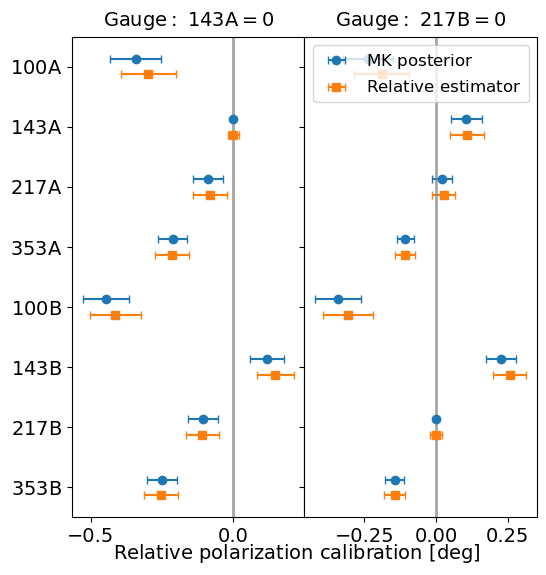

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(6, 6), sharey=True,
                          gridspec_kw={'wspace': 0, 'top': 0.90, 'bottom': 0.10})

labels = GAUGE_143A['labels']
y = np.arange(len(labels))

for i, (ax, ref) in enumerate(zip(axes, REFS)):
    r = GAUGES[ref]
    ax.errorbar(r['alpha_mk'], y - 0.13, xerr=r['alpha_mk_err'], fmt='o', ms=6,
                color='C0', capsize=3, label=r'$\mathrm{MK\ posterior}$')
    ax.errorbar(r['alpha_rel'], y + 0.13, xerr=r['alpha_rel_err'], fmt='s', ms=6,
                color='C1', capsize=3, label=r'$\mathrm{Relative\ estimator}$')
    ax.axvline(0, lw=2, color='grey',alpha=0.7)
    ax.set_title(rf'$\mathrm{{Gauge:\ {ref}=0}}$', fontsize=14, pad=8)
    if i == 1:
        ax.legend(frameon=True, fontsize=12, loc='upper right')

axes[0].set_yticks(y)
axes[0].set_yticklabels([rf'$\mathrm{{{lbl}}}$' for lbl in labels], fontsize=14)
axes[0].invert_yaxis()
axes[0].tick_params(axis='x', labelsize=14)
axes[1].tick_params(axis='x', labelsize=14)

fig.supxlabel(r'$\mathrm{Relative\ polarization\ calibration}\ [\mathrm{deg}]$', fontsize=14, y=0.02)
plt.show()